# Deep embedding clustering

Se comparan los métodos de clustering espacial utilizados en la literatura con el método DEC propuesto por Xie y co. 2016. Originalmente esta metodología no sigue restricciones espaciales que fueron agregadas a los fines de  este trabajo.

In [4]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from constantes import *
import SDEC.regionalizacion as reg
import matplotlib.pyplot as plt
import SDEC.deep_cluster as dc
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import os
import sys
from constantes import *

from datos.scripts_preproceso.lectura_datos_covid import *
import SDEC.regionalizacion as reg
import matplotlib.pyplot as plt
import SDEC.deep_cluster as dc

%matplotlib inline

In [2]:
from SDEC.datos.codigos.lectura_datos import *
#import regionalizacion as reg
import matplotlib.pyplot as plt
import SDEC.regionalizacion.deep_cluster as dc
from sklearn.cluster import KMeans, AgglomerativeClustering
#import rpy2.robjects as ro
import pickle 
import copy
dir_datos = "datos"

%matplotlib inline
%load_ext autoreload
%autoreload 2
#%load_ext rpy2.ipython

ModuleNotFoundError: No module named 'SDEC.datos'

In [5]:
covid,geo, centroides, codiprov,covid_acum,personas = df_covid()

c:\Users\Pablo\miniconda3\envs\sdec\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver ESRI Shapefile does not support open option INDEX
  return ogr_read(


El mes desde el cuál todos los dptos tienen al menos 1 contagiado es: 2021-01


## Armado de regiones

Se forman 6 regiones que van a tener comportamientos diferentes entre sí. Dentro de cada región los departamentos tienen el mismo comportamiento de base.

In [6]:
codiprov.groupby('provincia').describe()

regiones = {'noroeste' : ('Jujuy','Salta','Tucumán','Santiago del Estero','Catamarca'),
            'noreste'  : ('Formosa', 'Chaco', 'Misiones','Corrientes','Santa Fe','Entre Ríos'),
            'cuyo' : ('La Rioja','San Juan','Mendoza','San Luis'),
            'pampeana' : ('Córdoba', 'La Pampa', 'Buenos Aires','Ciudad Autónoma de Buenos Aires' ),
            'patagonia' : ('Neuquén', 'Río Negro', 'Chubut', 'Santa Cruz', 'Tierra del Fuego')    
    }


lista_regiones = []
errores = []
for i in range(len(codiprov)):
    prov = codiprov.iloc[i].provincia
    j = 1
    pertenece = False
    for k in regiones.keys():
        l = regiones[k]
        if prov in l:
            lista_regiones.append(j)
            pertenece = True
        else:
        
            pass
        j += 1
    if pertenece == False:
        errores.append(codiprov.iloc[i]) 


cov =  covid.loc[pd.IndexSlice[:,'2021-01'],:].copy()
cov['reg'] = lista_regiones

regiones = cov.reg.copy()
regiones[cov.provincia == "Tucumán"] = 6
cov['reg'] = regiones

El comportamiento de cada región va estar dado por una función base que depende del periodo de tiempo, en esta caso son funciones cuadráticas que la única variación que tienen entre regiones es el valor máximo y el periodo en que llegan al mismo. Se considera el comportamiento de dos variables por cada departamento. Dado el problema que tenemos lo que se va modificando es la tasa de proporción de la población de cada departamento.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipe = Pipeline([('standard', StandardScaler())#,
                 #('normalizer', Normalizer('l1'))
                 ])

func = {1 : lambda x : 0.14-((x-50)/100)**2,
     2 : lambda x : 0.25-((x-30)/100)**2,
     3 : lambda x : 0.20-((x-80)/100)**2,
     4 : lambda x : 0.10-((x-50)/100)**2,
     5 : lambda x : 0.3-((x-50)/100)**2,
     6 : lambda x : 0.3-((x-50)/100)**2
     }

x = cov.reg.map(func)


func2 = {1 : lambda x : 0.14-((2*x-90)/160)**2,
     2 : lambda x : 0.25-((2*x-100)/160)**2,
     3 : lambda x : 0.20-((2*x-150)/160)**2,
     4 : lambda x : 0.20-((2*x-100)/160)**2,
     5 : lambda x : 0.15-((2*x-120)/160)**2,
     6 : lambda x : 0.3-((2*x-120)/160)**2
     }

x2 = cov.reg.map(func2)

Para agregar ruido al modelo, por cada departamento se le agega un componente aleatorio que proviene de una distribución uniforme con intérvalo $[a,b) con b > a$ pero como se trata de proporciones se controla que dicho valor no sea menor a 0. Por lo tanto la fórmula de la proporción por departamento queda asi:

$x_t = f_R(t) + (b-a)*rand + a $

$y_t = x_t, si x_t > 0 $

$y_t = 0; en caso contrario$

siendo $f_R(t)$  la función de la resgión a la que pertenece el área.


In [8]:
np.random.seed(3264)

def genera_datos(periodos,amplitud):
  periodos = periodos
  p = np.arange(0,periodos)
  varianz = amplitud

  val = []
  for i in x:
      y = i(p)+(np.random.rand()-0.5)*varianz
      val.append(y)
  val = np.array(val)

  val2 = []
  for i in x2:
      y = i(p)+(np.random.rand()-0.5)*varianz
      val2.append(y)
  val2 = np.array(val2)
  v = np.c_[(val * (val > 0)),(val2 * (val2 > 0))] 
  return v

En este primer caso tomamos el modelo más sencillo dónde no existe el componente aleatorio

In [9]:
sim1 = genera_datos(100,0.05)
sim1_st = pipe.fit_transform(sim1)

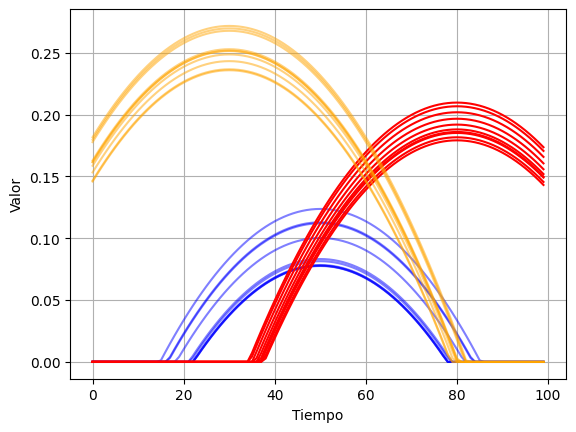

In [10]:
fig, ax = plt.subplots()
ax = pd.DataFrame(sim1[cov.reg.values == 4][:10,:100]).T.plot(legend = False, color = 'blue', ax = ax, alpha = 0.5)
ax = pd.DataFrame(sim1[cov.reg.values == 3][:10,:100]).T.plot(legend = False, color = 'red', ax = ax)
ax = pd.DataFrame(sim1[cov.reg.values == 2][:10,:100]).T.plot(legend = False, color = 'orange', ax = ax, alpha = 0.5)
#ax = pd.DataFrame(sim1[cov.reg.values == 1][:5]).T.plot(legend = False, color = 'green', ax = ax, alpha = 0.5)
ax.set_xlabel('Tiempo')
ax.set_ylabel('Valor')
#ax.set_axis_off()
ax.grid()

In [11]:
from libpysal.weights import KNN

In [12]:
W_knn = KNN.from_dataframe(cov, ids = cov.index.get_level_values(0), k = 6 )

In [13]:
aglo_esp = AgglomerativeClustering(6, connectivity= W_knn.sparse)
aglo_esp.fit(sim1_st)
km = KMeans(6)
km.fit(sim1_st)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


<Axes: >

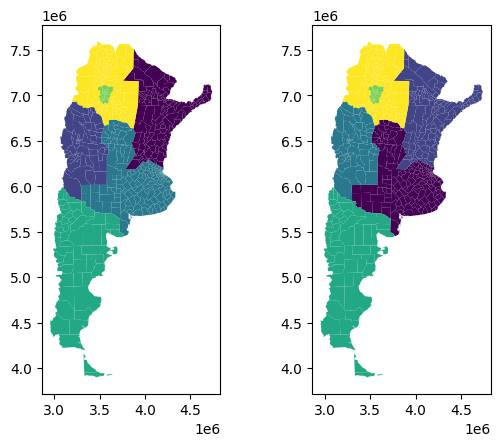

In [14]:
fig, ax = plt.subplots(1,2)
cov.plot(aglo_esp.labels_, ax = ax[0])
cov.plot(km.labels_, ax = ax[1])

In [15]:
from sklearn.metrics import *
def metricas_intrinsecas(datos, grupos):
    sil = round(silhouette_score(datos,grupos),5)
    cal = round(calinski_harabasz_score(datos,grupos),5)
    dav = round(davies_bouldin_score(datos, grupos),5)
    rdo = pd.DataFrame([sil,cal,dav], index = ['Siluetas', 'Kalinski','Davies'])
    return rdo

def metricas_extrinsecas(y_verd, y_pred):
    ami = adjusted_mutual_info_score(y_verd, y_pred)
    mi = mutual_info_score(y_verd, y_pred)
    hom = homogeneity_score(y_verd, y_pred)
    ran = rand_score(y_verd, y_pred)
    rdo = pd.DataFrame([ami,mi,hom,ran], index = ['Adj Mutual Inf', 'Mutual Inf', 'Homog','Rand score'])
    return rdo


In [16]:
metricas_intrinsecas(sim1_st, km.labels_)

,0
Siluetas,0.71932
Kalinski,1932.46309
Davies,0.35967


In [17]:
metricas_extrinsecas(cov.reg, km.labels_)

,0
Adj Mutual Inf,1.000000
Mutual Inf,1.586498
Homog,1.000000
Rand score,1.000000


Cómo se ve en este primer caso todos los algoritmos llegan al resultado perfecto. Así lo marcan las métricas de rendimiento también que tienen valores altos para todas las cálculadas. El índice LQ es el único que no llega a valor 1 como debíera marcar, pero este se calcula en base a intérvalos de confianza y  el resultado dado puede que no este bien separado en este sentido. 

Cabe aclarar que los algoritmos NO espaciales en este caso han funcionado bien pero porque no hay variabilidad y las regiones construidas son por esencia espaciales, en caso de que alguno de estos parámetros varíe encuentran resultados mucho más desordenados en el territorio

### Caso 2

En el segundo caso vamos a tomar una amplitud del espacio random de 0.5

In [18]:
np.random.seed(3264)

sim2 = genera_datos(100,0.5)
sim2_st = pipe.fit_transform(sim2)

gdf = gpd.GeoDataFrame(sim2_st, columns = np.array(range(200), str), geometry = cov.reset_index().geometry)
#gdf.to_file("SDEC/datos/simulaciones/sim2.shp")

In [19]:
km.fit(sim2_st)
aglo_esp.fit(sim2_st)
rdos_ext = pd.concat([metricas_extrinsecas(cov.reg, km.labels_),metricas_extrinsecas(cov.reg, aglo_esp.labels_)], axis = 1)
rdos_ext.columns = ['K-means','Aglo espacial']
rdos_ext

,K-means,Aglo espacial
Adj Mutual Inf,0.219080,0.571125
Mutual Inf,0.379392,0.901121
Homog,0.239138,0.567994
Rand score,0.698909,0.763548


<Axes: >

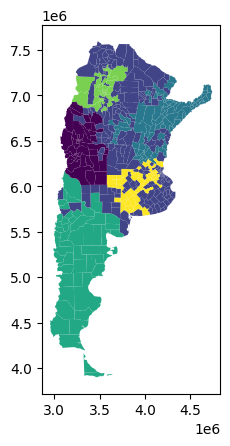

In [20]:
cov.plot(aglo_esp.labels_)

In [21]:
rdos_int = pd.concat([metricas_intrinsecas(sim2_st, km.labels_),metricas_intrinsecas(sim2_st, aglo_esp.labels_)], axis = 1)
rdos_int.columns = ['K-means','Aglo espacial']
rdos_int

,K-means,Aglo espacial
Siluetas,0.31822,0.10604
Kalinski,246.30880,57.95331
Davies,1.12228,2.94145


In [22]:
sim1_st.shape

(525, 200)

In [23]:
def calc_sdec(datos, W):
    X = datos
    X1 = datos[:,:100]
    X2 = datos[:,100:]
    sdec = dc.sdec(6)
    sdec.gen_modelo()
    sdec.train_autoencoder([X1,X2],X)
    sdec.ajustar_modelo([X1,X2], W.sparse)
    return sdec

In [24]:
sdec = calc_sdec(sim2_st, W_knn)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
delta_label  0.0 < tol  0.0001
Reached tolerance threshold. Stopping training.


In [25]:
rdos_ext['SDEC'] = metricas_extrinsecas(cov.reg,sdec.y_pred)
rdos_ext

,K-means,Aglo espacial,SDEC
Adj Mutual Inf,0.219080,0.571125,0.944183
Mutual Inf,0.379392,0.901121,1.503554
Homog,0.239138,0.567994,0.947719
Rand score,0.698909,0.763548,0.987190


In [26]:
rdos_int['SDEC'] = metricas_intrinsecas(sim2_st,sdec.y_pred)
rdos_int

,K-means,Aglo espacial,SDEC
Siluetas,0.31822,0.10604,0.00866
Kalinski,246.30880,57.95331,37.73764
Davies,1.12228,2.94145,4.37000


In [27]:
sdec.autoencoder.evaluate([sim2_st[:,:100],sim2_st[:,100:]],sim2_st)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -0.3107 


-0.3106958568096161

In [31]:
rdo_rgeoda = pd.read_csv(os.path.join(DIR_RESULTADOS, "simulaciones/simul_R.csv"), index_col = 0)

In [32]:
rdos_int['skater'] = metricas_intrinsecas(sim2_st,rdo_rgeoda.skater)
rdos_int['redcap'] = metricas_intrinsecas(sim2_st,rdo_rgeoda.redcap)
rdos_int['schc'] = metricas_intrinsecas(sim2_st,rdo_rgeoda.schc)
rdos_int

,K-means,Aglo espacial,SDEC,skater,redcap,schc
Siluetas,0.31822,0.10604,0.00866,0.07455,0.10535,0.13320
Kalinski,246.30880,57.95331,37.73764,36.26427,43.75215,3.49700
Davies,1.12228,2.94145,4.37000,3.11341,2.52550,0.62007


In [33]:
rdos_ext['skater'] = metricas_extrinsecas(cov.reg,rdo_rgeoda.skater)
rdos_ext['redcap'] = metricas_extrinsecas(cov.reg,rdo_rgeoda.redcap)
rdos_ext['schc'] = metricas_extrinsecas(cov.reg,rdo_rgeoda.schc)
rdos_ext

,K-means,Aglo espacial,SDEC,skater,redcap,schc
Adj Mutual Inf,0.219080,0.571125,0.944183,0.629987,0.606403,0.026365
Mutual Inf,0.379392,0.901121,1.503554,0.912408,0.864784,0.037714
Homog,0.239138,0.567994,0.947719,0.575108,0.545090,0.023772
Rand score,0.698909,0.763548,0.987190,0.762101,0.752955,0.255914


Cuando agegamos ruido a los modelos ya los métodos que no son espaciales presentan severas dificultades para encontrar la respuesta, presentan resultados muy desordenados.

Los métodos espaciales que se presentan por rgeoda no trabajan mal, el que mejor lo hace es el método skater sin considerar los autoencoders. 

Pero para este caso con mayor variabilidad el método propuesto DEC supera ampliamente a todos los demás. Esto se puede ver visualmente y tambien por el indicador de mutual información. El problema que hay es con las métricas intrínseca. Estas arrojan valores peores que los demás modelos, pero si vemos la salida del resultado real, vemos que son muy similares a estas, lo que está fallando en este caso son las métricas.

### Caso 3

Tomammos una amplitud de 1

In [34]:
np.random.seed(3264)

sim3 = genera_datos(100,1)
sim3_st =  pipe.fit_transform(sim3)

gdf = gpd.GeoDataFrame(sim3_st, columns = np.array(range(200), str), geometry = cov.reset_index().geometry)
#gdf.to_file("SDEC/datos/simulaciones/sim3.shp")

In [ ]:
sdec = calc_sdec(sim3_st, W_knn)



17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


,K-means,Aglo espacial,SDEC,skater,redcap,schc
Adj Mutual Inf,0.219080,0.571125,0.836565,0.629987,0.606403,0.026365
Mutual Inf,0.379392,0.901121,1.320478,0.912408,0.864784,0.037714
Homog,0.239138,0.567994,0.832323,0.575108,0.545090,0.023772
Rand score,0.698909,0.763548,0.943083,0.762101,0.752955,0.255914


<Axes: >

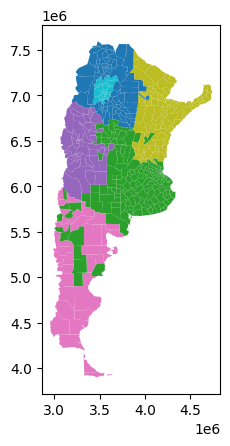

In [36]:
cov.plot(sdec.y_pred, categorical = True)

In [ ]:
#pd.DataFrame(sdec.y_pred, columns = ['SDEC']).to_csv('Resultados/sdec_simul3.csv')

In [45]:
rdo_rgeoda = pd.read_csv(os.path.join(DIR_RESULTADOS, "simulaciones/simul3_R.csv"), index_col = 0)

In [46]:
rdos_int['SDEC'] = metricas_intrinsecas(sim3_st,sdec.y_pred)
rdos_int['skater'] = metricas_intrinsecas(sim3_st,rdo_rgeoda.skater)
rdos_int['redcap'] = metricas_intrinsecas(sim3_st,rdo_rgeoda.redcap)
rdos_int['schc'] = metricas_intrinsecas(sim3_st,rdo_rgeoda.schc)
rdos_int

,K-means,Aglo espacial,SDEC,skater,redcap,schc
Siluetas,0.31822,0.10604,-0.05424,-0.05590,-0.05315,0.03836
Kalinski,246.30880,57.95331,15.84020,18.28857,24.66595,3.05062
Davies,1.12228,2.94145,7.25977,2.92953,2.90883,0.59956


In [50]:
rdos_ext['SDEC'] = metricas_extrinsecas(cov.reg,sdec.y_pred)
rdos_ext['skater'] = metricas_extrinsecas(cov.reg,rdo_rgeoda.skater)
rdos_ext['redcap'] = metricas_extrinsecas(cov.reg,rdo_rgeoda.redcap)
rdos_ext['schc'] = metricas_extrinsecas(cov.reg,rdo_rgeoda.schc)
rdos_ext

,K-means,Aglo espacial,SDEC,skater,redcap,schc
Adj Mutual Inf,0.219080,0.571125,0.836565,0.404106,0.372873,0.016914
Mutual Inf,0.379392,0.901121,1.320478,0.535890,0.544100,0.028901
Homog,0.239138,0.567994,0.832323,0.337782,0.342956,0.018217
Rand score,0.698909,0.763548,0.943083,0.579280,0.666041,0.252177


In [48]:
X1 = sim3_st[:,:100]
X2 = sim3_st[:,100:]

pred = sdec.autoencoder.predict([X1,X2])

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [49]:
mean_squared_error(pred, sim3_st)

0.9950631428710741